# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [2]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_held,131.17,8.3037,2.7,330,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_held,-0.063
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_held,H,leucine_held,e,3600,0.02
water,H,leucine_held,e,3012.835,0.029995
water,e,leucine_held,H,3012.835,0.029995
"""
components = ["water", "leucine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[2])
println("Tm = ", model1.solid.params.Tm[2])

[353.94 363.2913502876169; 363.2913502876169 330.0]
[2.8014570000000003e-10 2.7507285000000004e-10; 2.7507285000000004e-10 2.7000000000000005e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 3012.835, 3012.835, 3600.0]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.029995, 0.029995, 0.02]
kij = -0.06299999999999994
Hfus = 37411.34
Tm = 620.9



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0           0.00185217
   2 │      273.544         0.00230677
   3 │      277.089         0.00284684
   4 │      280.633         0.00348166
   5 │      284.178         0.00421996
   6 │      287.722         0.00506963
   7 │      291.267         0.00603748
   8 │      294.811         0.00712905
   9 │      298.356         0.00834854
  10 │      301.9           0.0096988
  11 │      305.444         0.0111814
  12 │      308.989         0.0127969
  13 │      312.533         0.0145449
  14 │      316.078         0.0164241
  15 │      319.622         0.018433
  16 │      323.167         0.0205696
  17 │      326.711         0.0228318
  18 │      330.256         0.0252172
  19 │      333.8           0.0277238
  20 │      337.344         0.0303495
  21 │      340.889         0.0330926
  22 │      344.433      

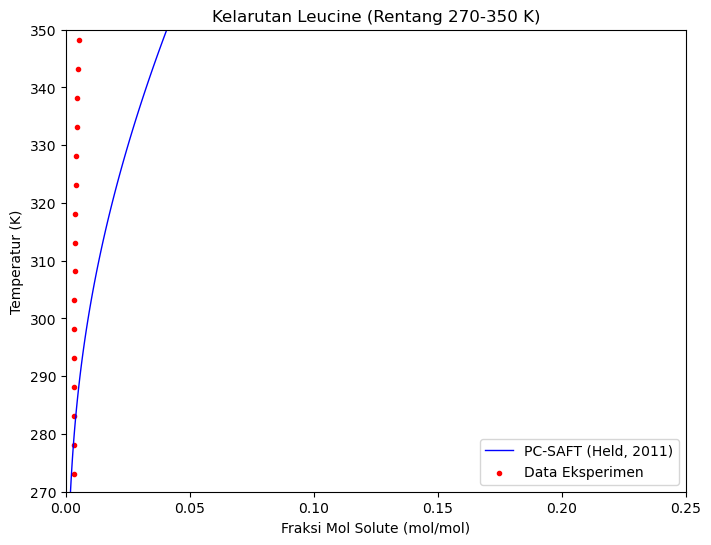

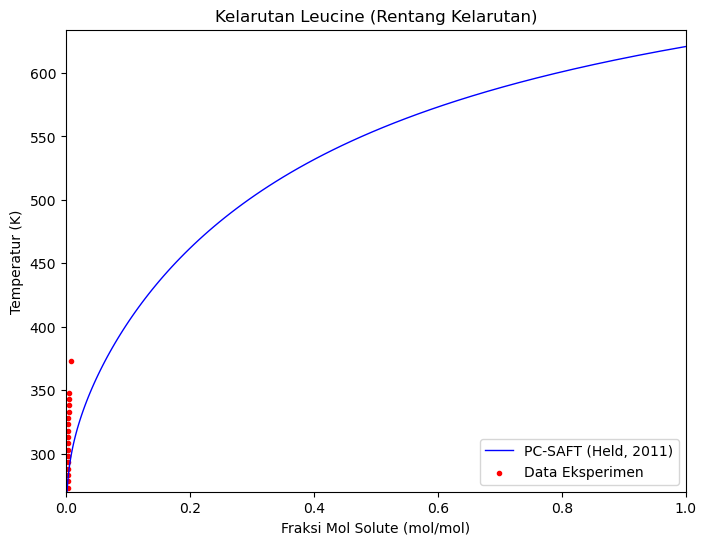

In [58]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["leucine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model1.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model1, p, T[i], [1., 1.]; solute=["leucine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, 634.138)
    
    plt.legend(loc="lower right")
    plt.savefig("1_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [4]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["leucine_gclow"])[2]
    return x2
end

function solubility_gcmid(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["leucine_gcmid"])[2]
    return x2
end

function solubility_gcup(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["leucine_gcup"])[2]
    return x2
end

function solubility_held(model::EoSModel, T::Float64)
    p = 101325
    x2 = sle_solubility(model,p,T,[1.,1.];solute=["leucine_held"])[2]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [5]:
aard_p   = calculate_AAD(model1, "sol_leucine.csv", solubility_held)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.002252      27.5567 
278.1500    0.003124      0.003027      3.1142  
283.1500    0.003151      0.003995      26.7717 
288.1500    0.003193      0.005180      62.2085 
293.1500    0.003251      0.006602      103.0832
298.1500    0.003322      0.008274      149.0940
303.1500    0.003409      0.010207      199.3924
308.1500    0.003515      0.012403      252.7980
313.1500    0.003638      0.014862      308.5048
318.1500    0.003783      0.017583      364.8150
323.1500    0.003950      0.020559      420.4272
328.1500    0.004143      0.023785      474.1654
333.1500    0.004362      0.027255      524.8450
338.1500    0.004614      0.030963      571.0923
343.1500    0.004900      0.034903      612.3729
348.1500    0.005225      0.039072      647.8463
373.1500    0.007686      0.063264      723.1229
AARD = 321.8359%


321.83591801269046

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [6]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_gclow,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcmid,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcup,131.17,6.93266,2.913617,297.3468,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_gclow,0.133761
water,leucine_gcmid,0.133761
water,leucine_gcup,0.133761
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_gclow,H,leucine_gclow,e,3218.409692,0.030798
leucine_gcmid,H,leucine_gcmid,e,3218.409692,0.030798
leucine_gcup,H,leucine_gcup,e,3218.409692,0.030798
water,H,leucine_gclow,e,2822.04,0.037206
water,e,leucine_gclow,H,2822.04,0.037206
water,H,leucine_gcmid,e,2822.04,0.037206
water,e,leucine_gcmid,H,2822.04,0.037206
water,H,leucine_gcup,e,2822.04,0.037206
water,e,leucine_gcup,H,2822.04,0.037206
"""
components_low = ["water", "leucine_gclow"]
components_mid = ["water", "leucine_gcmid"]
components_up = ["water", "leucine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 23148.84
Tm = 536.5279
mid bound
Hfus = 27690.0
Tm = 582.55
up bound
Hfus = 32231.16
Tm = 628.5707



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    2.39875e-11  5.37773e-12  1.116e-12
   2 │      272.692  3.45691e-11  7.90632e-12  1.67384e-12
   3 │      275.384  4.94596e-11  1.15356e-11  2.49049e-12
   4 │      278.077  7.02703e-11  1.67071e-11  3.67692e-12
   5 │      280.769  9.91619e-11  2.40245e-11  5.38784e-12
   6 │      283.461  1.39014e-10  3.43077e-11  7.83749e-12
   7 │      286.153  1.93643e-10  4.86638e-11  1.13205e-11
   8 │      288.845  2.68073e-10  6.85779e-11  1.62393e-11
   9 │      291.538  3.68888e-10  9.60306e-11  2.31407e-11
  10 │      294.23   5.04665e-10  1.33648e-10  3.27623e-11
  11 │      296.922  6.86517e-10  1.84893e-10  4.60938e-11
  12 │      299.614  9.28775e-10  2.54307e-10  6.44552e-11
  13 │      302.306  1.24983e-9   3.47814e-10  8.95979e-11
  14 │

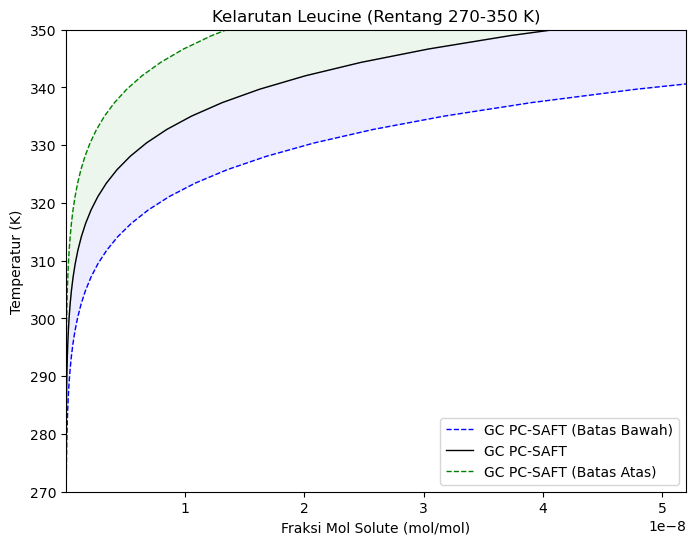

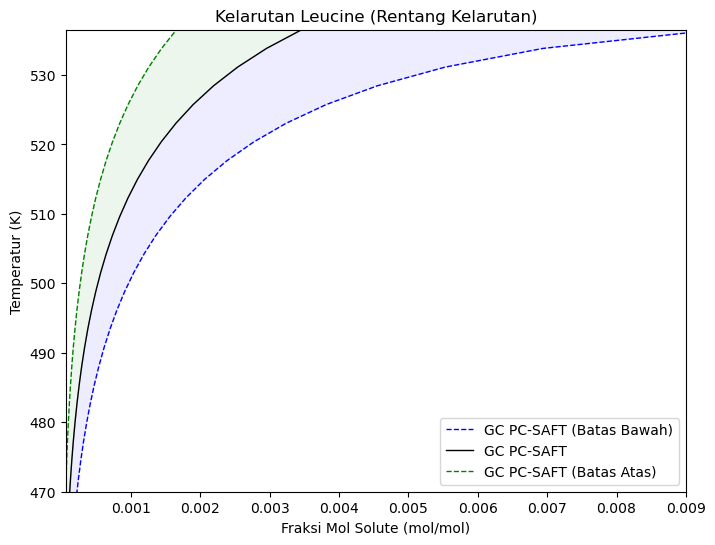

In [59]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(1e-12, 5.2e-8)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end


function plot_x(df)
    T = LinRange(270., model2_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model2_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model2_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model2_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end


    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6e-5, 0.009)
    plt.ylim(470, model2_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("2_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [11]:
aard_p   = calculate_AAD(model2_low, "sol_leucine.csv", solubility_gclow)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      99.9999 
313.1500    0.003638      0.000000      99.9999 
318.1500    0.003783      0.000000      99.9998 
323.1500    0.003950      0.000000      99.9997 
328.1500    0.004143      0.000000      99.9996 
333.1500    0.004362      0.000000      99.9994 
338.1500    0.004614      0.000000      99.9991 
343.1500    0.004900      0.000000      99.9987 
348.1500    0.005225      0.000000      99.9981 
373.1500    0.007686      0.000001      99.9911 
AARD = 99.9991%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99913187250928

In [12]:
aard_p   = calculate_AAD(model2_mid, "sol_leucine.csv", solubility_gcmid)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      99.9999 
323.1500    0.003950      0.000000      99.9999 
328.1500    0.004143      0.000000      99.9999 
333.1500    0.004362      0.000000      99.9998 
338.1500    0.004614      0.000000      99.9997 
343.1500    0.004900      0.000000      99.9995 
348.1500    0.005225      0.000000      99.9993 
373.1500    0.007686      0.000000      99.9965 
AARD = 99.9997%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99967829242507

In [13]:
aard_p   = calculate_AAD(model2_up, "sol_leucine.csv", solubility_gcup)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      100.0000
323.1500    0.003950      0.000000      100.0000
328.1500    0.004143      0.000000      100.0000
333.1500    0.004362      0.000000      99.9999 
338.1500    0.004614      0.000000      99.9999 
343.1500    0.004900      0.000000      99.9999 
348.1500    0.005225      0.000000      99.9998 
373.1500    0.007686      0.000000      99.9987 
AARD = 99.9999%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99988897020758

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [14]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_held,131.17,6.93266,2.913617,297.3468,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_held,0.185853
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_held,H,leucine_held,e,3218.409692,0.030798
water,H,leucine_held,e,2822.04,0.037206
water,e,leucine_held,H,2822.04,0.037206
"""
components = ["water", "leucine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 264.11878132007286; 264.11878132007286 297.3468]
[2.8014570000000003e-10 2.857537e-10; 2.857537e-10 2.913617e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2822.04, 2822.04, 3218.409692]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.037206, 0.037206, 0.030798]
kij = 0.18585299999999993
Hfus = 37411.34
Tm = 620.9



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Temperatur_K  Fraksi_Mol_Solute 
     │ Float64       Float64           
─────┼─────────────────────────────────
   1 │      270.0          9.19446e-16
   2 │      273.544        1.76272e-15
   3 │      277.089        3.32318e-15
   4 │      280.633        6.16492e-15
   5 │      284.178        1.12611e-14
   6 │      287.722        2.02662e-14
   7 │      291.267        3.59547e-14
   8 │      294.811        6.29165e-14
   9 │      298.356        1.08649e-13
  10 │      301.9          1.85246e-13
  11 │      305.444        3.11991e-13
  12 │      308.989        5.19277e-13
  13 │      312.533        8.54482e-13
  14 │      316.078        1.39069e-12
  15 │      319.622        2.2395e-12
  16 │      323.167        3.56965e-12
  17 │      326.711        5.63386e-12
  18 │      330.256        8.80726e-12
  19 │      333.8          1.36417e-11
  20 │      337.344        2.09424e-11
  21 │      340.889        3.18743e-11
  22 │      3

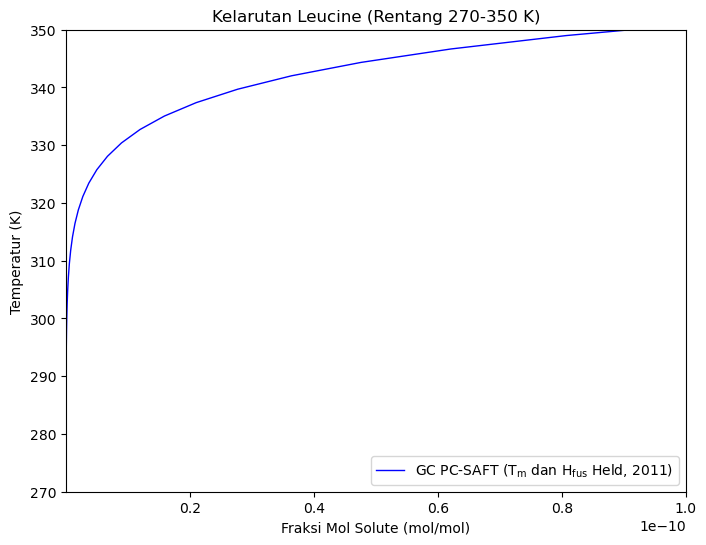

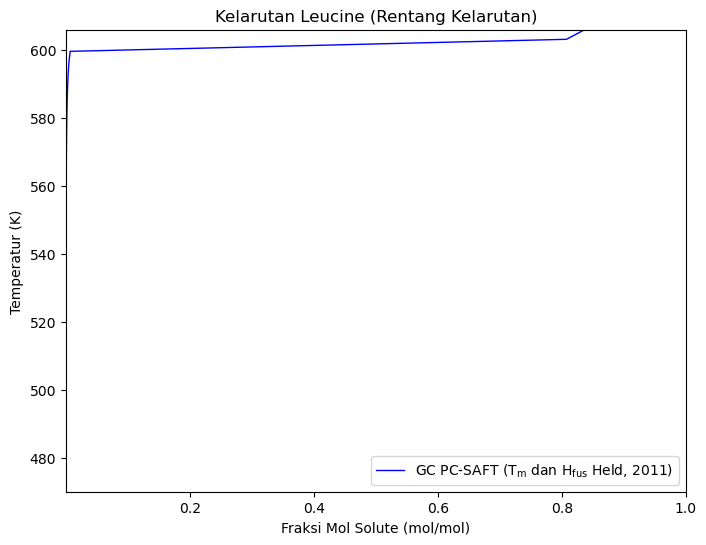

In [61]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["leucine_held"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(9e-16, 1.e-10)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model3.solid.params.Tm[2], 100)
    p = 101325 
    s = zeros(length(T))
    for i in 1:length(T)
        s[i] = sle_solubility(model3, p, T[i], [1., 1.]; solute=["leucine_held"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(Temperatur_K = T, Fraksi_Mol_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s, T, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(2e-6, 1)
    plt.ylim(470, 606)
    
    plt.legend(loc="lower right")
    plt.savefig("3_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [66]:
aard_p   = calculate_AAD(model3, "sol_leucine.csv", solubility_held)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      100.0000
323.1500    0.003950      0.000000      100.0000
328.1500    0.004143      0.000000      100.0000
333.1500    0.004362      0.000000      100.0000
338.1500    0.004614      0.000000      100.0000
343.1500    0.004900      0.000000      100.0000
348.1500    0.005225      0.000000      100.0000
373.1500    0.007686      0.000000      100.0000
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99999901539714

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [20]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_gclow,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcmid,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcup,131.17,6.93266,2.913617,297.3468,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_gclow,-0.063
water,leucine_gcmid,-0.063
water,leucine_gcup,-0.063
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_gclow,H,leucine_gclow,e,3218.409692,0.030798
leucine_gcmid,H,leucine_gcmid,e,3218.409692,0.030798
leucine_gcup,H,leucine_gcup,e,3218.409692,0.030798
water,H,leucine_gclow,e,2822.04,0.037206
water,e,leucine_gclow,H,2822.04,0.037206
water,H,leucine_gcmid,e,2822.04,0.037206
water,e,leucine_gcmid,H,2822.04,0.037206
water,H,leucine_gcup,e,2822.04,0.037206
water,e,leucine_gcup,H,2822.04,0.037206
"""
components_low = ["water", "leucine_gclow"]
components_mid = ["water", "leucine_gcmid"]
components_up = ["water", "leucine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 23148.84
Tm = 536.5279
mid bound
Hfus = 27690.0
Tm = 582.55
up bound
Hfus = 32231.16
Tm = 628.5707



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low      X_Mid      X_Up       
     │ Float64       Float64    Float64    Float64    
─────┼────────────────────────────────────────────────
   1 │      270.0    0.0427795  0.0162379  0.0046145
   2 │      272.692  0.0455515  0.0177801  0.00525041
   3 │      275.384  0.0484068  0.0194003  0.0059468
   4 │      278.077  0.0513452  0.0210979  0.00670561
   5 │      280.769  0.0543666  0.0228723  0.00752849
   6 │      283.461  0.057471   0.024723   0.00841676
   7 │      286.153  0.0606585  0.0266492  0.00937147
   8 │      288.845  0.0639291  0.0286506  0.0103934
   9 │      291.538  0.0672832  0.0307265  0.011483
  10 │      294.23   0.0707209  0.0328767  0.0126407
  11 │      296.922  0.0742426  0.0351006  0.0138665
  12 │      299.614  0.0778487  0.0373982  0.0151604
  13 │      302.306  0.0815396  0.0397691  0.0165223
  14 │      304.999  0.0853158  0.0422131  0.017952
  15 │      307.691  0.089178   0.0447303

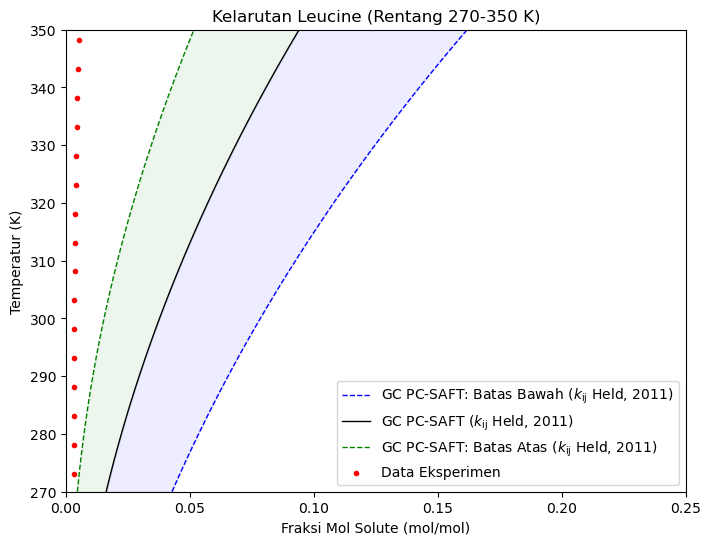

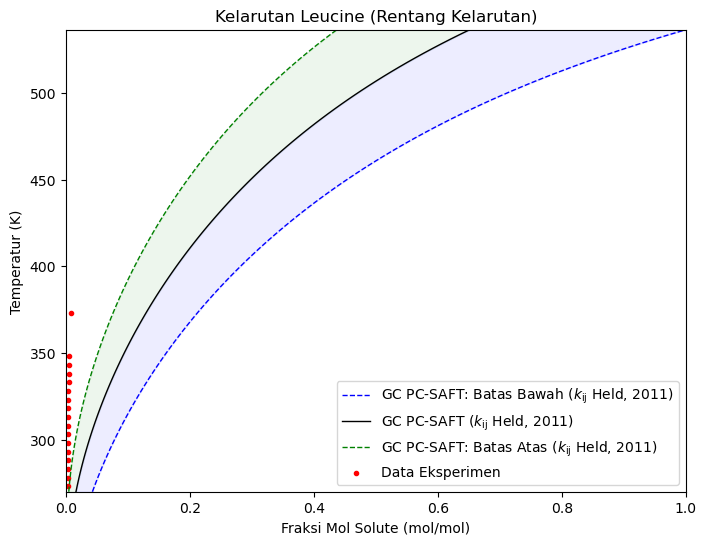

In [62]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.25)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model4_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model4_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model4_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model4_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model4_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("4_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [63]:
aard_p   = calculate_AAD(model4_low, "sol_leucine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.046031      1380.6684
278.1500    0.003124      0.051426      1546.2644
283.1500    0.003151      0.057108      1712.3067
288.1500    0.003193      0.063076      1875.1798
293.1500    0.003251      0.069332      2032.7836
298.1500    0.003322      0.075877      2184.2503
303.1500    0.003409      0.082714      2326.2780
308.1500    0.003515      0.089845      2455.6982
313.1500    0.003638      0.097276      2573.6986
318.1500    0.003783      0.105010      2675.9801
323.1500    0.003950      0.113052      2761.7306
328.1500    0.004143      0.121408      2830.7111
333.1500    0.004362      0.130084      2882.2786
338.1500    0.004614      0.139088      2914.6201
343.1500    0.004900      0.148427      2929.4014
348.1500    0.005225      0.158109      2926.2594
373.1500    0.007686      0.212014      2658.4778
AARD = 2392.1522%


2392.152188987361

In [64]:
aard_p   = calculate_AAD(model4_mid, "sol_leucine.csv", solubility_gcmid)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.018050      480.6111
278.1500    0.003124      0.021145      576.9027
283.1500    0.003151      0.024505      677.6673
288.1500    0.003193      0.028126      780.7547
293.1500    0.003251      0.032005      884.5458
298.1500    0.003322      0.036140      987.9680
303.1500    0.003409      0.040527      1088.7981
308.1500    0.003515      0.045167      1184.7965
313.1500    0.003638      0.050059      1275.9056
318.1500    0.003783      0.055203      1359.3294
323.1500    0.003950      0.060602      1434.0373
328.1500    0.004143      0.066255      1499.3610
333.1500    0.004362      0.072166      1554.4707
338.1500    0.004614      0.078338      1597.9185
343.1500    0.004900      0.084774      1630.2412
348.1500    0.005225      0.091477      1650.9046
373.1500    0.007686      0.129173      1580.6547
AARD = 1190.8745%


1190.8745336984605

In [65]:
aard_p   = calculate_AAD(model4_up, "sol_leucine.csv", solubility_gcup)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.005365      72.5583 
278.1500    0.003124      0.006727      115.3510
283.1500    0.003151      0.008311      163.7395
288.1500    0.003193      0.010123      216.9912
293.1500    0.003251      0.012168      274.3156
298.1500    0.003322      0.014448      334.9587
303.1500    0.003409      0.016963      397.5838
308.1500    0.003515      0.019711      460.6954
313.1500    0.003638      0.022691      523.6730
318.1500    0.003783      0.025900      584.6678
323.1500    0.003950      0.029335      642.5829
328.1500    0.004143      0.032997      696.5225
333.1500    0.004362      0.036882      745.5520
338.1500    0.004614      0.040991      788.4461
343.1500    0.004900      0.045323      825.0435
348.1500    0.005225      0.049878      854.6875
373.1500    0.007686      0.076051      889.4918
AARD = 505.1095%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


505.10945882798063

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [25]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_gclow,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcmid,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcup,131.17,6.93266,2.913617,297.3468,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_gclow,0
water,leucine_gcmid,0
water,leucine_gcup,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_gclow,H,leucine_gclow,e,3218.409692,0.030798
leucine_gcmid,H,leucine_gcmid,e,3218.409692,0.030798
leucine_gcup,H,leucine_gcup,e,3218.409692,0.030798
water,H,leucine_gclow,e,2822.04,0.037206
water,e,leucine_gclow,H,2822.04,0.037206
water,H,leucine_gcmid,e,2822.04,0.037206
water,e,leucine_gcmid,H,2822.04,0.037206
water,H,leucine_gcup,e,2822.04,0.037206
water,e,leucine_gcup,H,2822.04,0.037206
"""
components_low = ["water", "leucine_gclow"]
components_mid = ["water", "leucine_gcmid"]
components_up = ["water", "leucine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 23148.84
Tm = 536.5279
mid bound
Hfus = 27690.0
Tm = 582.55
up bound
Hfus = 32231.16
Tm = 628.5707



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    9.02016e-5   2.01278e-5   4.17253e-6
   2 │      272.692  0.00010929   2.48578e-5   5.25585e-6
   3 │      275.384  0.000131939  3.0572e-5    6.59014e-6
   4 │      278.077  0.000158727  3.74492e-5   8.22657e-6
   5 │      280.769  0.000190319  4.56958e-5   1.02253e-5
   6 │      283.461  0.000227471  5.55501e-5   1.26569e-5
   7 │      286.153  0.000271047  6.72858e-5   1.56037e-5
   8 │      288.845  0.000322035  8.1217e-5    1.91616e-5
   9 │      291.538  0.000381558  9.77033e-5   2.3442e-5
  10 │      294.23   0.000450903  0.000117156  2.85738e-5
  11 │      296.922  0.000531535  0.000140042  3.47057e-5
  12 │      299.614  0.000625132  0.000166897  4.20089e-5
  13 │      302.306  0.000733617  0.000198327  5.06799e-5
  14 │      304.99

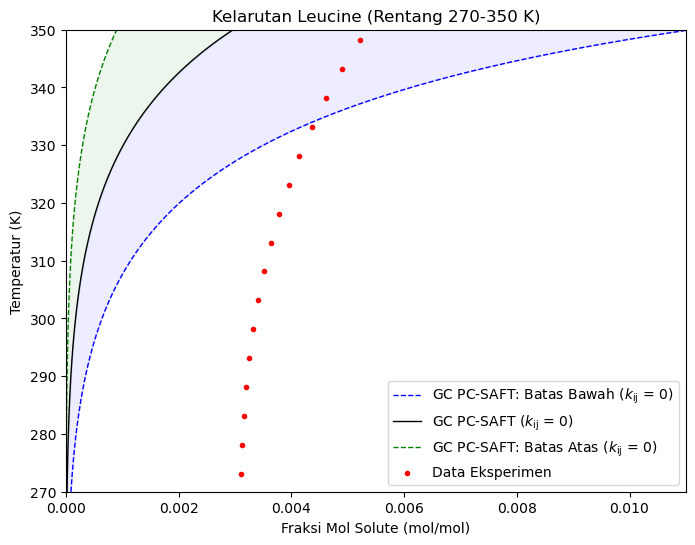

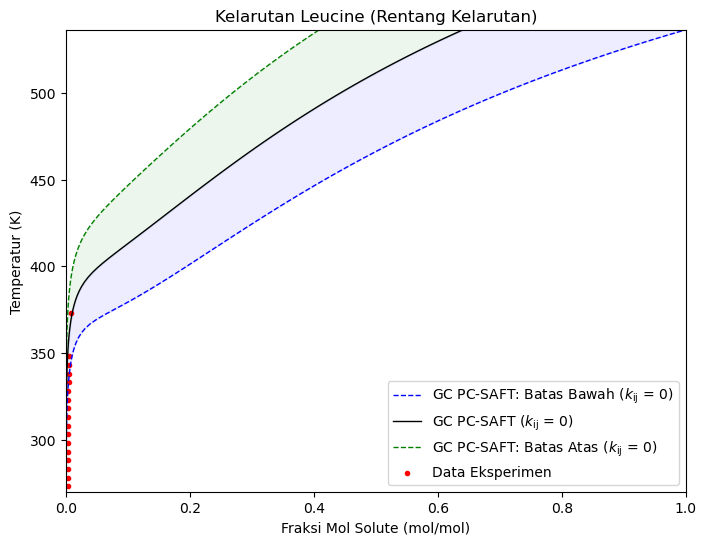

In [67]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 350., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 0.011)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model5_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model5_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model5_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model5_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ = 0)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ = 0)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ = 0)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(0.0, 1)
    plt.ylim(270.0, model5_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("5_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [30]:
aard_p   = calculate_AAD(model5_low, "sol_leucine.csv", solubility_gclow)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000113      96.3692 
278.1500    0.003124      0.000160      94.8934 
283.1500    0.003151      0.000223      92.9274 
288.1500    0.003193      0.000308      90.3523 
293.1500    0.003251      0.000422      87.0240 
298.1500    0.003322      0.000573      82.7648 
303.1500    0.003409      0.000771      77.3834 
308.1500    0.003515      0.001031      70.6627 
313.1500    0.003638      0.001372      62.2959 
318.1500    0.003783      0.001816      51.9829 
323.1500    0.003950      0.002398      39.3077 
328.1500    0.004143      0.003160      23.7169 
333.1500    0.004362      0.004167      4.4671  
338.1500    0.004614      0.005511      19.4569 
343.1500    0.004900      0.007337      49.7441 
348.1500    0.005225      0.009878      89.0595 
373.1500    0.007686      0.067632      779.9434
AARD = 106.6089%


106.60891511853006

In [31]:
aard_p   = calculate_AAD(model5_mid, "sol_leucine.csv", solubility_gcmid)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000026      99.1715 
278.1500    0.003124      0.000038      98.7946 
283.1500    0.003151      0.000054      98.2761 
288.1500    0.003193      0.000077      97.5766 
293.1500    0.003251      0.000109      96.6479 
298.1500    0.003322      0.000152      95.4312 
303.1500    0.003409      0.000209      93.8627 
308.1500    0.003515      0.000286      91.8725 
313.1500    0.003638      0.000387      89.3688 
318.1500    0.003783      0.000519      86.2686 
323.1500    0.003950      0.000693      82.4702 
328.1500    0.004143      0.000917      77.8576 
333.1500    0.004362      0.001208      72.3036 
338.1500    0.004614      0.001583      65.6798 
343.1500    0.004900      0.002067      57.8034 
348.1500    0.005225      0.002692      48.4779 
373.1500    0.007686      0.010177      32.4115 
AARD = 81.4279%


81.42792490973818

In [32]:
aard_p   = calculate_AAD(model5_up, "sol_leucine.csv", solubility_gcup)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000005      99.8243 
278.1500    0.003124      0.000008      99.7351 
283.1500    0.003151      0.000012      99.6080 
288.1500    0.003193      0.000018      99.4308 
293.1500    0.003251      0.000026      99.1878 
298.1500    0.003322      0.000038      98.8596 
303.1500    0.003409      0.000054      98.4244 
308.1500    0.003515      0.000075      97.8572 
313.1500    0.003638      0.000105      97.1261 
318.1500    0.003783      0.000144      96.2007 
323.1500    0.003950      0.000196      95.0448 
328.1500    0.004143      0.000264      93.6186 
333.1500    0.004362      0.000354      91.8805 
338.1500    0.004614      0.000471      89.7917 
343.1500    0.004900      0.000622      87.3028 
348.1500    0.005225      0.000817      84.3696 
373.1500    0.007686      0.002967      61.3990 
AARD = 93.5095%


93.50946372152717

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [33]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
leucine_gclow,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcmid,131.17,6.93266,2.913617,297.3468,2,2
leucine_gcup,131.17,6.93266,2.913617,297.3468,2,2
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
water,leucine_gclow,0.158554727
water,leucine_gcmid,0.158554727
water,leucine_gcup,0.158554727
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
water,H,water,e,2425.67,0.045
leucine_gclow,H,leucine_gclow,e,3218.409692,0.030798
leucine_gcmid,H,leucine_gcmid,e,3218.409692,0.030798
leucine_gcup,H,leucine_gcup,e,3218.409692,0.030798
water,H,leucine_gclow,e,2822.04,0.037206
water,e,leucine_gclow,H,2822.04,0.037206
water,H,leucine_gcmid,e,2822.04,0.037206
water,e,leucine_gcmid,H,2822.04,0.037206
water,H,leucine_gcup,e,2822.04,0.037206
water,e,leucine_gcup,H,2822.04,0.037206
"""
components_low = ["water", "leucine_gclow"]
components_mid = ["water", "leucine_gcmid"]
components_up = ["water", "leucine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 23148.84
Tm = 536.5279
mid bound
Hfus = 27690.0
Tm = 582.55
up bound
Hfus = 32231.16
Tm = 628.5707



=== HASIL PERHITUNGAN MODEL ===
100×4 DataFrame
 Row │ Temperatur_K  X_Low        X_Mid        X_Up        
     │ Float64       Float64      Float64      Float64     
─────┼─────────────────────────────────────────────────────
   1 │      270.0    1.46305e-12  3.28e-13     6.80674e-14
   2 │      272.692  2.17759e-12  4.98039e-13  1.05439e-13
   3 │      275.384  3.21573e-12  7.50016e-13  1.61925e-13
   4 │      278.077  4.71277e-12  1.12049e-12  2.46597e-13
   5 │      280.769  6.85594e-12  1.66102e-12  3.7251e-13
   6 │      283.461  9.90261e-12  2.44389e-12  5.583e-13
   7 │      286.153  1.42042e-11  3.56962e-12  8.30387e-13
   8 │      288.845  2.02376e-11  5.17714e-12  1.22595e-12
   9 │      291.538  2.86458e-11  7.45721e-12  1.79698e-12
  10 │      294.23   4.02911e-11  1.06701e-11  2.61566e-12
  11 │      296.922  5.63223e-11  1.51687e-11  3.78156e-12
  12 │      299.614  7.82623e-11  2.14289e-11  5.43125e-12
  13 │      302.306  1.08119e-10  3.00883e-11  7.75084e-12
  14 │ 

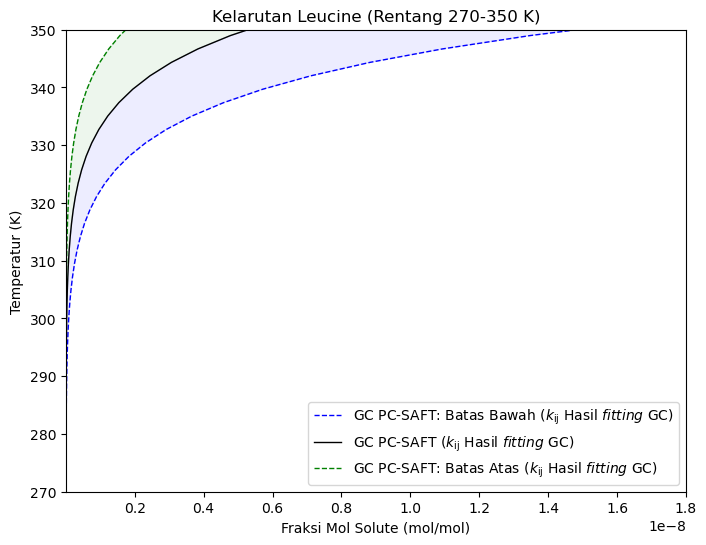

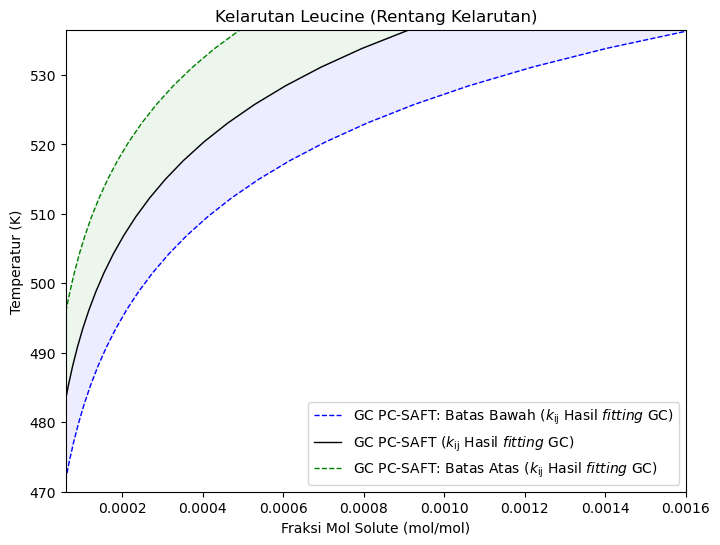

In [68]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_leucine.csv", DataFrame)

function plot_T(df)
    T = LinRange(270., 500., 100)
    p = 101325
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))

    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6.8e-14, 1.8e-8)
    plt.ylim(270.0, 350.0)
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_T_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

function plot_x(df)
    T = LinRange(270., model6_low.solid.params.Tm[2], 100)
    p = 101325
    
    s_low = zeros(length(T))
    s_mid = zeros(length(T))
    s_up = zeros(length(T))
    
    for i in 1:length(T)
        s_low[i] = sle_solubility(model6_low, p, T[i], [1., 1.]; solute=["leucine_gclow"])[2]
        s_mid[i] = sle_solubility(model6_mid, p, T[i], [1., 1.]; solute=["leucine_gcmid"])[2]
        s_up[i]  = sle_solubility(model6_up, p, T[i], [1., 1.]; solute=["leucine_gcup"])[2]
    end

    # Bikin DataFrame-nya dulu
    df_hasil = DataFrame(
        Temperatur_K = T,
        X_Low = s_low,
        X_Mid = s_mid,
        X_Up = s_up)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(s_low, T, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(s_mid, T, label=L"GC PC-SAFT ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="black", linestyle="-", linewidth=1.)
    plt.plot(s_up, T, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Hasil $fitting$ GC)", color="green", linestyle="--", linewidth=1.)

    plt.fill_betweenx(T, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_betweenx(T, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.out_x2, df.T, color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Leucine (Rentang Kelarutan)")
    plt.xlabel("Fraksi Mol Solute (mol/mol)")
    plt.ylabel("Temperatur (K)")
    
    plt.xlim(6e-5, 0.0016)
    plt.ylim(470.0, model6_low.solid.params.Tm[2])
    
    plt.legend(loc="lower right")
    plt.savefig("6_plot_x_leucine.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)
plot_x(df_eksperimen)

In [54]:
aard_p   = calculate_AAD(model6_low, "sol_leucine.csv", solubility_gclow)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      100.0000
323.1500    0.003950      0.000000      100.0000
328.1500    0.004143      0.000000      100.0000
333.1500    0.004362      0.000000      99.9999 
338.1500    0.004614      0.000000      99.9999 
343.1500    0.004900      0.000000      99.9998 
348.1500    0.005225      0.000000      99.9998 
373.1500    0.007686      0.000000      99.9986 
AARD = 99.9999%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99987993214025

In [55]:
aard_p   = calculate_AAD(model6_mid, "sol_leucine.csv", solubility_gcmid)


=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      100.0000
323.1500    0.003950      0.000000      100.0000
328.1500    0.004143      0.000000      100.0000
333.1500    0.004362      0.000000      100.0000
338.1500    0.004614      0.000000      100.0000
343.1500    0.004900      0.000000      99.9999 
348.1500    0.005225      0.000000      99.9999 
373.1500    0.007686      0.000000      99.9995 
AARD = 100.0000%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


99.99995507367767

In [57]:
aard_p   = calculate_AAD(model6_up, "sol_leucine.csv", solubility_gcup)

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593



=== AAD: sol_leucine.csv ===
Clapeyron Estimator  exp           calc          ARD%    
273.1500    0.003109      0.000000      100.0000
278.1500    0.003124      0.000000      100.0000
283.1500    0.003151      0.000000      100.0000
288.1500    0.003193      0.000000      100.0000
293.1500    0.003251      0.000000      100.0000
298.1500    0.003322      0.000000      100.0000
303.1500    0.003409      0.000000      100.0000
308.1500    0.003515      0.000000      100.0000
313.1500    0.003638      0.000000      100.0000
318.1500    0.003783      0.000000      100.0000
323.1500    0.003950      0.000000      100.0000
328.1500    0.004143      0.000000      100.0000
333.1500    0.004362      0.000000      100.0000
338.1500    0.004614      0.000000      100.0000
343.1500    0.004900      0.000000      100.0000
348.1500    0.005225      0.000000      100.0000
373.1500    0.007686      0.000000      99.9998 
AARD = 100.0000%


99.99998435885767